In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.io as pio

In [2]:
df =  pd.read_csv('../data/auto-mpg.csv')

In [3]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [4]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [5]:
non_numeric_hp = df[~df['horsepower'].str.replace('.','',1).str.isnumeric()]['horsepower'].unique()
print("Non-numeric horsepower values: ", non_numeric_hp)

Non-numeric horsepower values:  <StringArray>
['?']
Length: 1, dtype: str


In [6]:
df['horsepower'] = pd.to_numeric(df['horsepower'].replace('?', np.nan))
print(df['horsepower'].isnull().sum())

6


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(4), int64(4), str(1)
memory usage: 28.1 KB


In [8]:
mean_hp = df['horsepower'].mean()
df['horsepower'] = df['horsepower'].fillna(mean_hp)
print(df['horsepower'].isnull().sum())

0


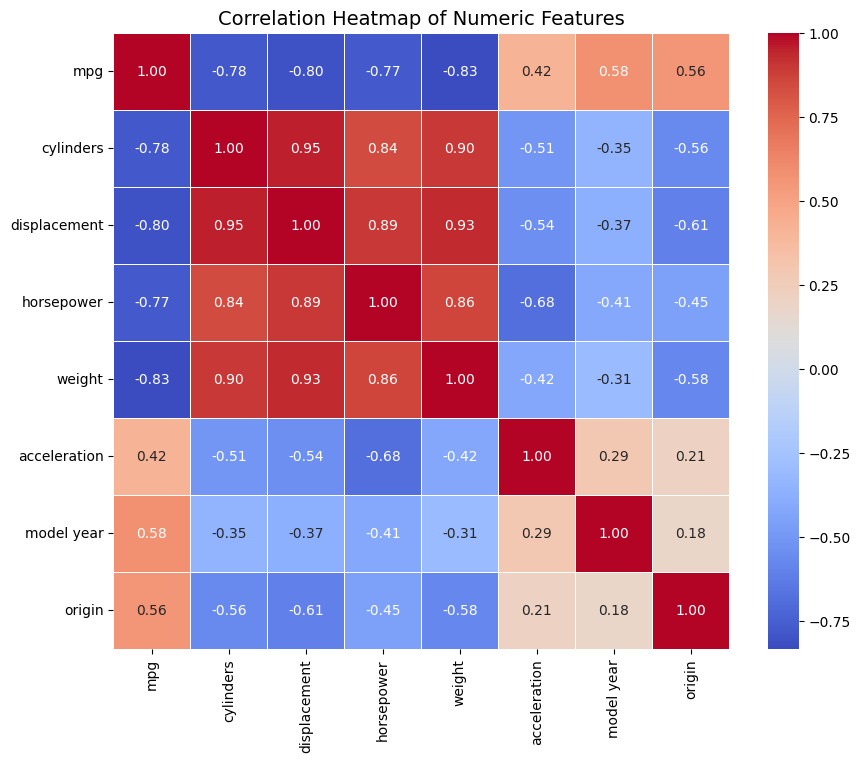

In [9]:
corr = df.select_dtypes(include=['float64', 'int64']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt = '.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14)
plt.show()

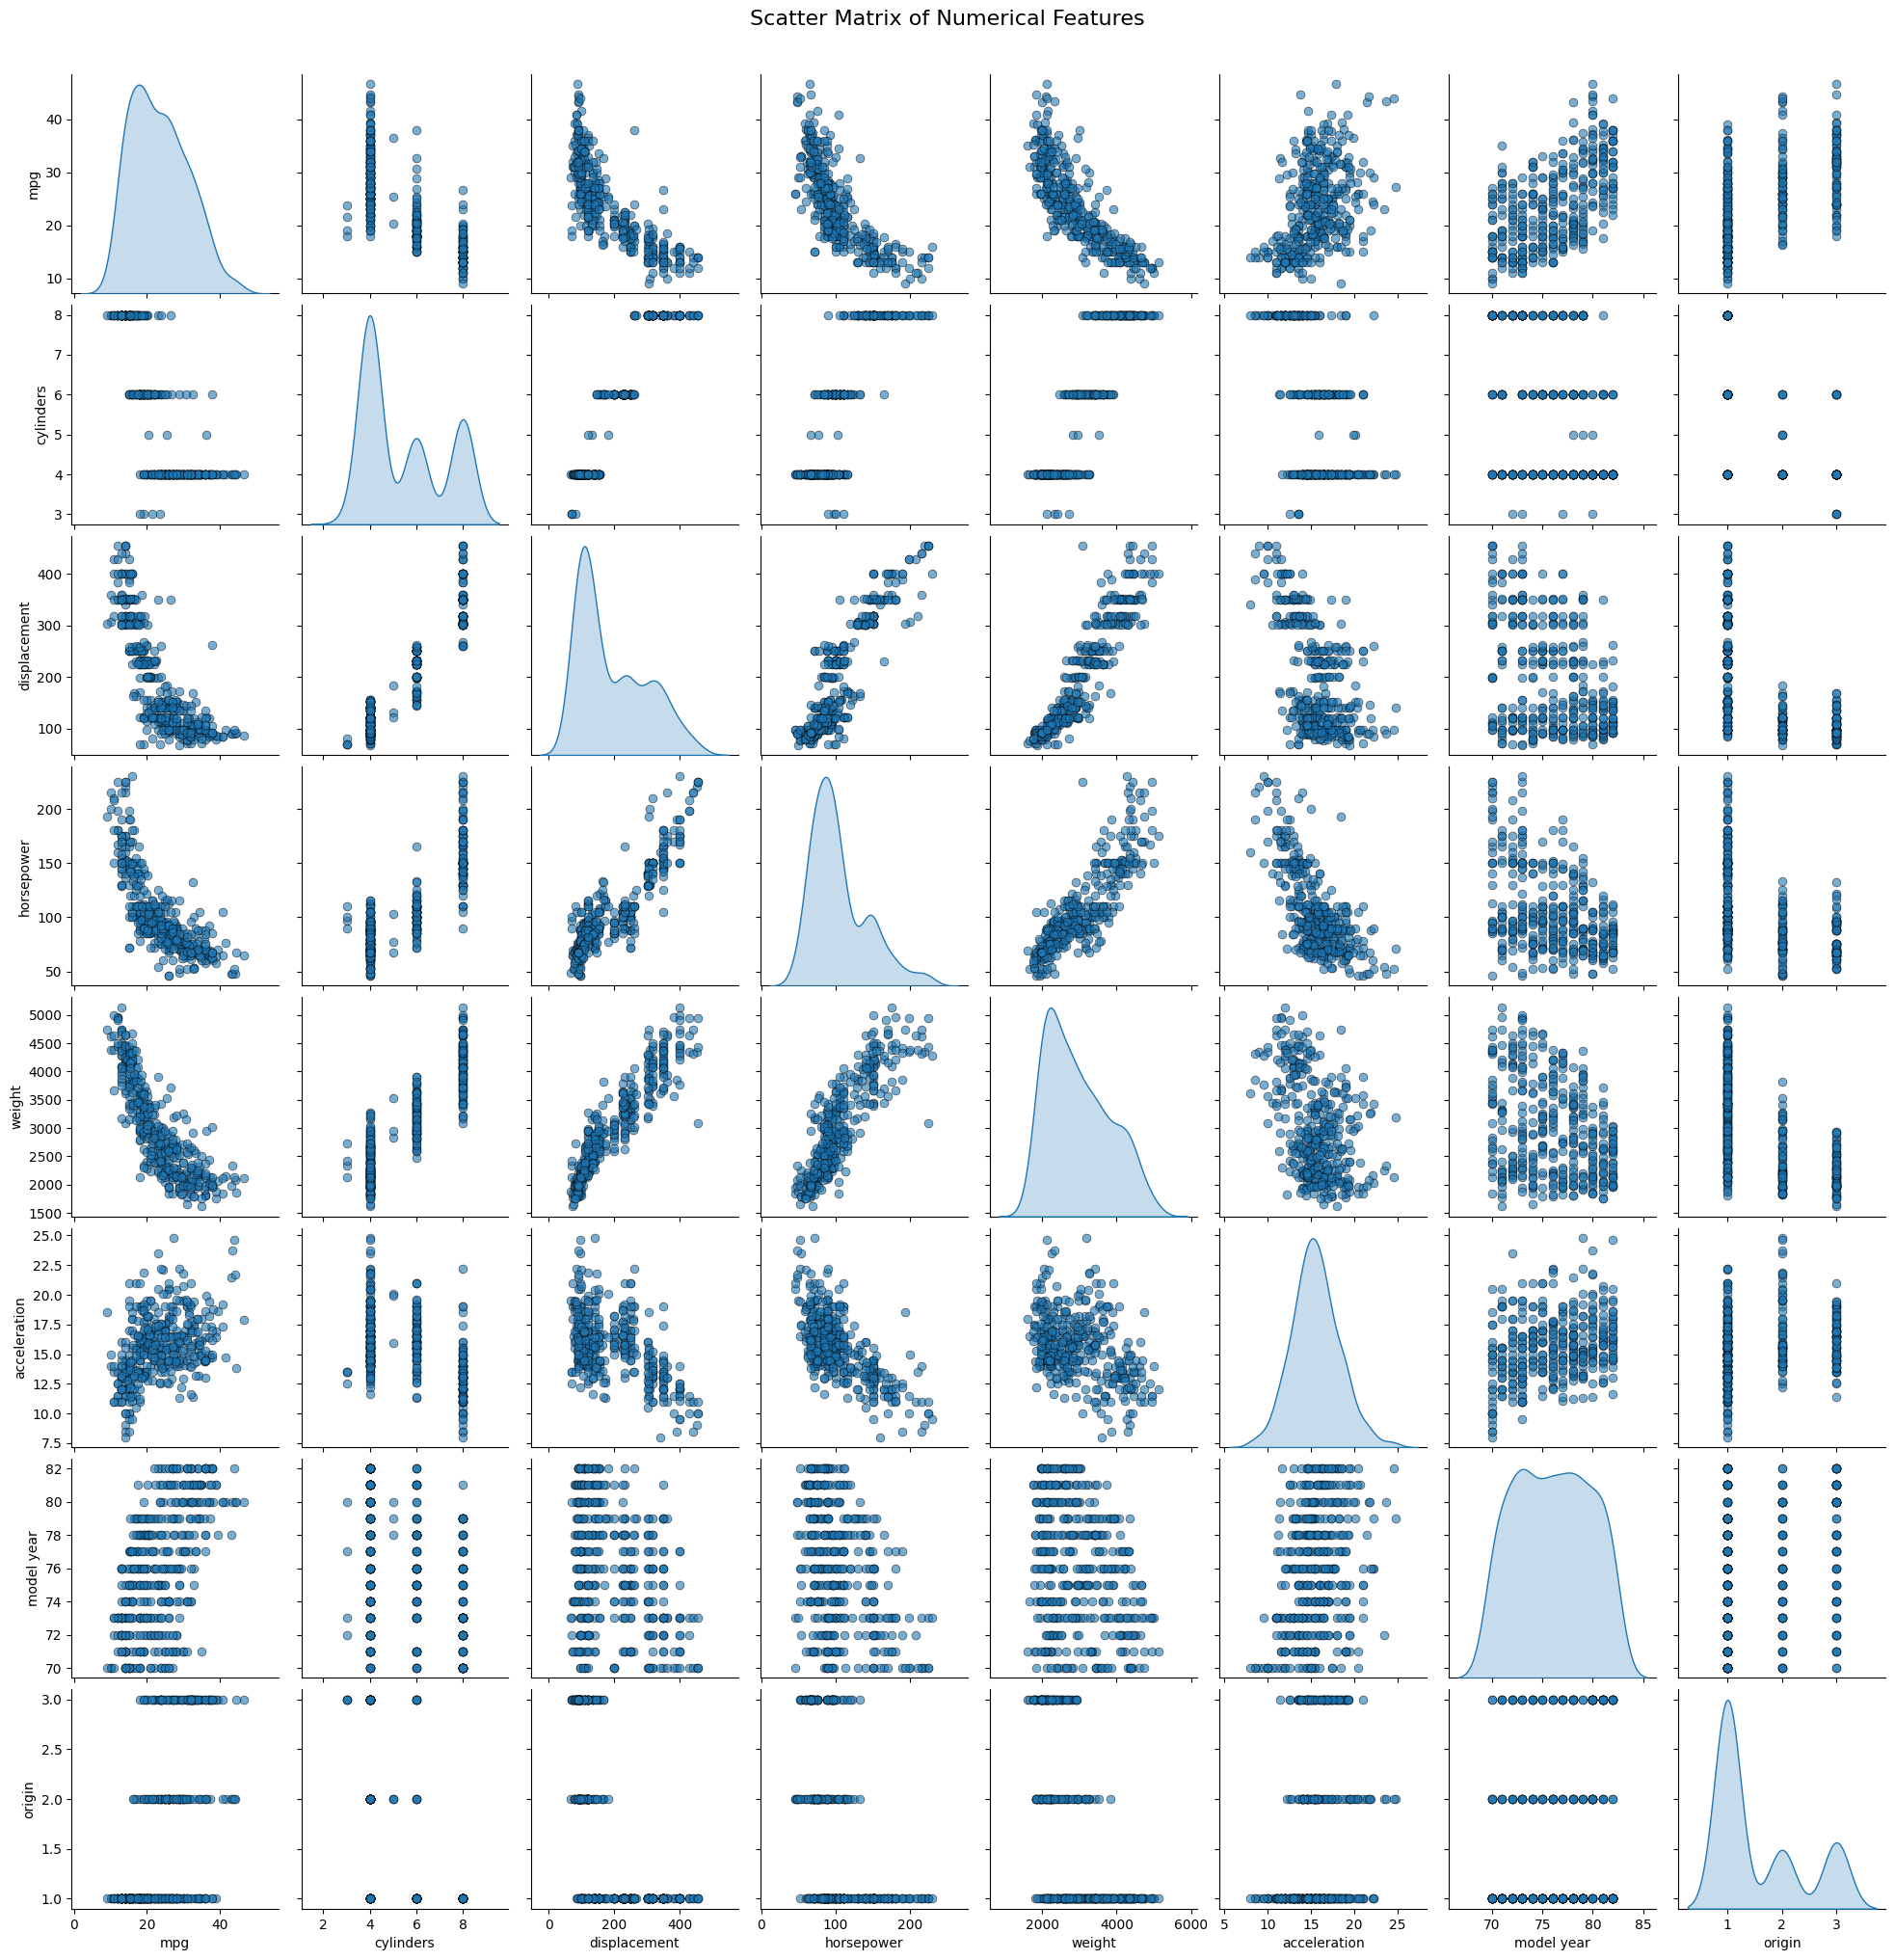

In [10]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.pairplot(numeric_df, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'k'})
plt.suptitle('Scatter Matrix of Numerical Features', fontsize=16, y=1.02)
plt.show()

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df.drop(columns=['car name', 'origin'])

X = add_constant(X)

vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,Feature,VIF
0,const,757.031966
1,mpg,5.227504
2,cylinders,10.604849
3,displacement,19.765922
4,horsepower,8.644376
5,weight,13.429119
6,acceleration,2.510462
7,model year,1.910226


## PCA

In [12]:
X = df.drop(columns=['car name', 'origin'])

scaler = StandardScaler()

X_scaler = scaler.fit_transform(X)

In [13]:
pca = PCA()

X_pca = pca.fit_transform(X_scaler)

In [14]:
pio.renderers.default = "iframe"
components = list(range(1, len(pca.explained_variance_ratio_) + 1))
variance_ratio = pca.explained_variance_ratio_

fig = px.line(
    x=components, 
    y=variance_ratio, 
    markers=True,
    labels={'x': 'Principal Component', 'y': 'Explained Variance Ratio'},
    title="Scree Plot"
)

fig.update_layout(width=800, height=500)
fig.show()

In [15]:
explained_variance = pd.DataFrame({
    'Principal Component' : [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Explained Variance Ratio': pca.explained_variance_ratio_, 
    'Cumulative Variance': np.cumsum(pca.explained_variance_ratio_)
})
print("Explained Variance per Principal Component:")
display(explained_variance.round(4))

Explained Variance per Principal Component:


,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.7142,0.7142
1,PC2,0.1237,0.8379
2,PC3,0.1041,0.9420
3,PC4,0.0267,0.9687
4,PC5,0.0182,0.9869
5,PC6,0.0081,0.9950
6,PC7,0.0050,1.0000


In [16]:
loadings = pd.DataFrame(pca.components_.T, 
                        columns = [f'PC{i+1}' for i in range(len(X.columns))], 
                        index = X.columns)
print("Principal Components Loading:")
display(loadings.round(4))

Principal Components Loading:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
mpg,-0.3979,0.2118,-0.2562,0.7477,0.3295,0.2356,-0.0898
cylinders,0.4166,0.1911,0.1409,0.4851,-0.4730,-0.3562,-0.4290
displacement,0.4299,0.1770,0.1037,0.2942,-0.0649,0.1465,0.8129
horsepower,0.4217,0.0918,-0.1680,-0.0393,0.7385,-0.4846,-0.0610
weight,0.4144,0.2215,0.2798,-0.1133,0.2264,0.7064,-0.3713
acceleration,-0.2848,-0.0245,0.8927,0.1262,0.2432,-0.2084,0.0534
model year,-0.2294,0.9106,-0.0172,-0.2980,-0.0877,-0.1371,0.0508


In [17]:
X_pca_3 = X_pca[:, :3]

df_pca = pd.DataFrame(X_pca_3, columns = ['PC1', 'PC2', 'PC3'])



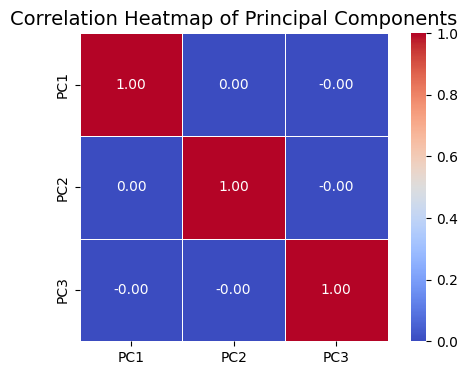

In [18]:
corr_pca = df_pca[['PC1', 'PC2', 'PC3']].corr()

plt.figure(figsize= (6, 4))

sns.heatmap(corr_pca, annot=True, cmap='coolwarm', fmt = '.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Principal Components', fontsize=14)
plt.show()

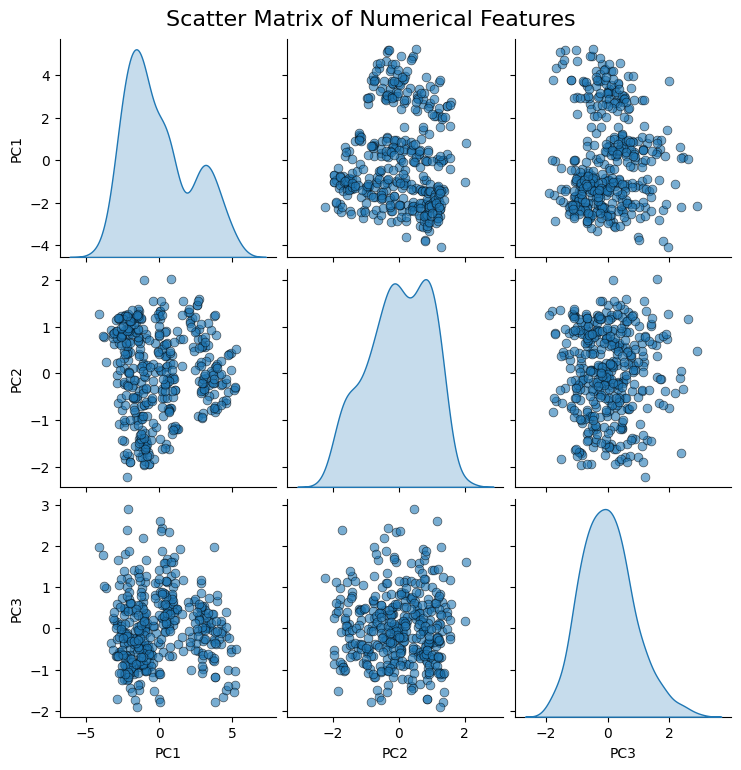

In [19]:
sns.pairplot(df_pca[['PC1', 'PC2', 'PC3']], diag_kind='kde', plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'k'})
plt.suptitle('Scatter Matrix of Numerical Features', fontsize=16, y=1.02)
plt.show()

In [20]:
X = df_pca[['PC1', 'PC2', 'PC3']]

X = add_constant(X)

vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,Feature,VIF
0,const,1.0
1,PC1,1.0
2,PC2,1.0
3,PC3,1.0
